In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# X = np.load("X_filtered.npy")
# y = np.load("y_filtered.npy")

# print(X.shape, y.shape)

(81, 64, 64, 18) (81, 64, 64)


In [2]:
X_train=np.load("X_train0.npy")
X_test=np.load("X_test0.npy")
y_train=np.load("y_train0.npy")
y_test=np.load("y_test0.npy")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60, 64, 64, 18) (60, 64, 64, 1)
(61, 64, 64, 18) (61, 64, 64, 1)


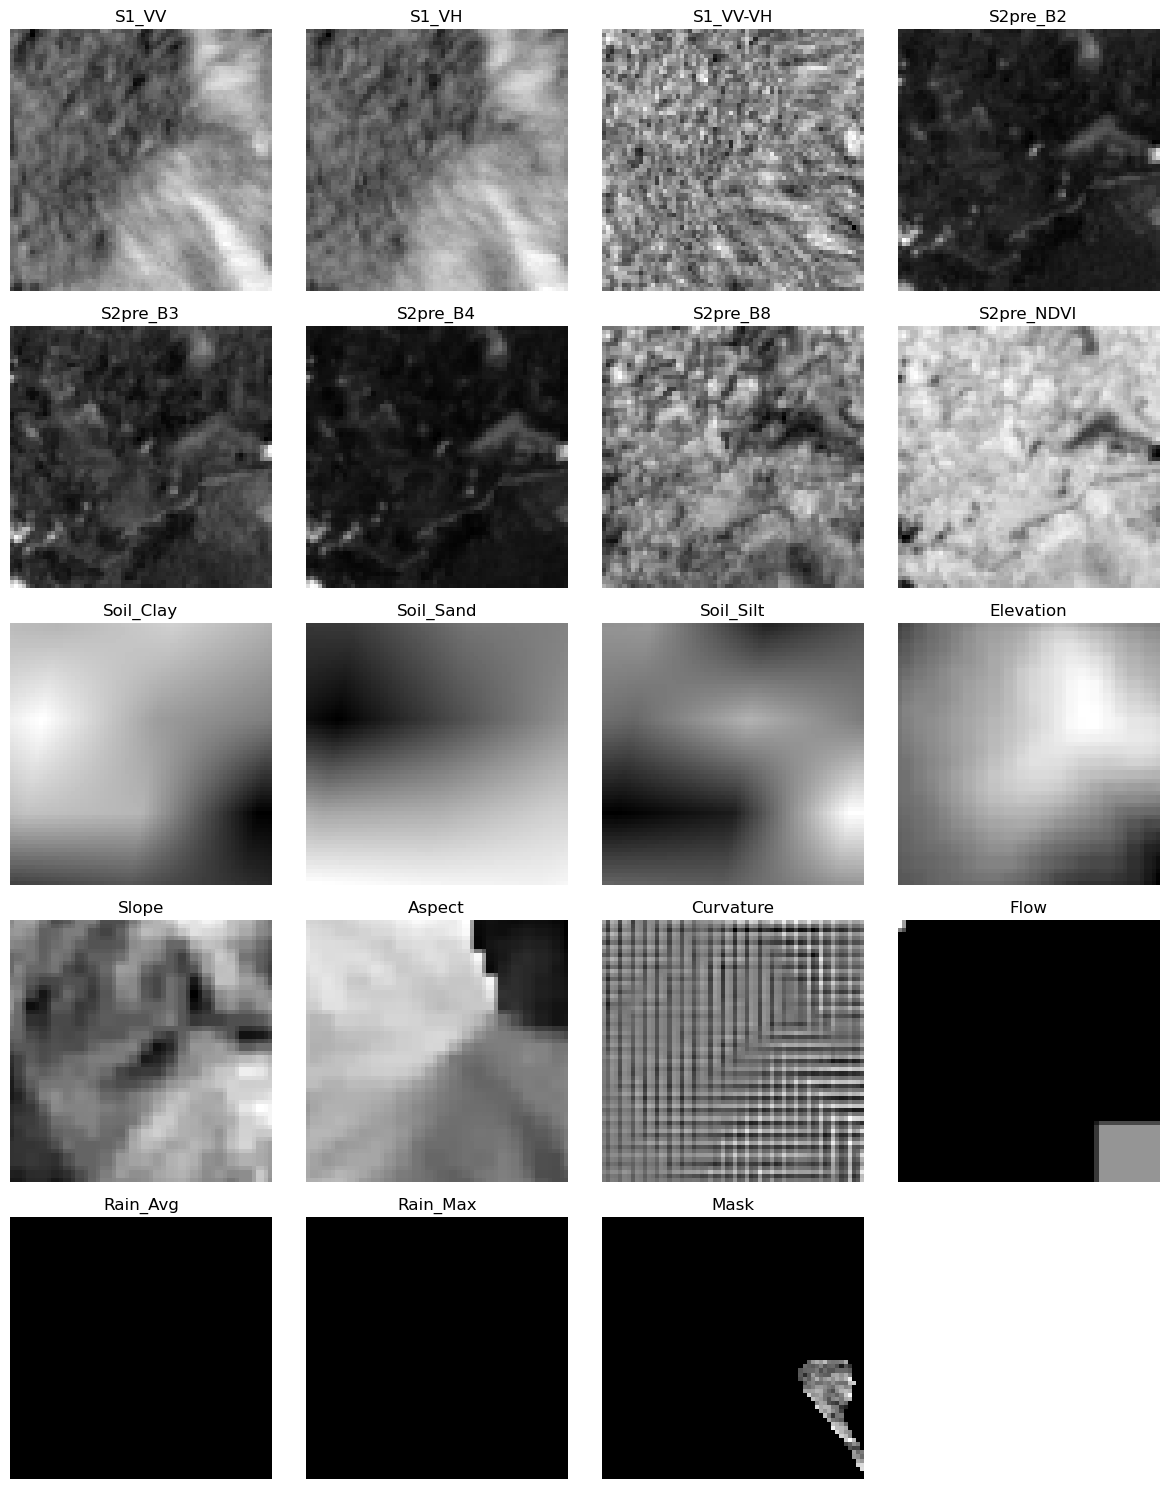

In [271]:
band_names_full = [
    "S1_VV", "S1_VH", "S1_VV-VH",

    "S2pre_B2", "S2pre_B3", "S2pre_B4", "S2pre_B8", "S2pre_NDVI",

    "Soil_Clay", "Soil_Sand", "Soil_Silt",

    "Elevation", "Slope", "Aspect", "Curvature", "Flow",

    "Rain_Avg", "Rain_Max"
]

keep = [i for i in range(len(band_names_full))]
band_names = [band_names_full[i] for i in keep]

import matplotlib.pyplot as plt

i = 0

X = X_train
y = y_train

num_bands = X.shape[3]
cols = 4
rows = (num_bands + 1 + cols - 1) // cols

plt.figure(figsize=(12, 3*rows))

for b in range(num_bands):
    plt.subplot(rows, cols, b + 1)
    plt.imshow(X[i][:,:,b], cmap='gray')
    plt.title(band_names[b])   # ✅ actual name
    plt.axis('off')

# Mask
plt.subplot(rows, cols, num_bands + 1)
plt.imshow(y[i][:,:,0], cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [142]:
# X = X.astype(np.float32)

# for b in range(X.shape[3]):
#     X[:,:,:,b] = (X[:,:,:,b] - X[:,:,:,b].mean()) / (X[:,:,:,b].std() + 1e-6)

In [143]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [3]:
X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
y_train = torch.tensor(y_train).permute(0, 3, 1, 2).float()

X_test = torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_test = torch.tensor(y_test).permute(0, 3, 1, 2).float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [4]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=True
)

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.d1 = DoubleConv(in_channels, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)

        self.bn = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)
        # self.skip_proj = nn.Conv2d(5, 1, kernel_size=1)
        self.fuse = nn.Conv2d(in_channels=19, out_channels=1, kernel_size=1)

    def forward(self, x):
        x_in = x   # save input

        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))

        bn = self.bn(self.p3(d3))

        u3 = self.u3(bn)
        u3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(u3)
        u2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(u2)
        u1 = self.c1(torch.cat([u1, d1], dim=1))

        out = self.out(u1)                          # (B,1,H,W)
        s2_pre = x_in[:, :, :, :]                 # (B,5,H,W)

        fused = torch.cat([out, s2_pre], dim=1)     # (B,6,H,W)

        out = self.fuse(fused)                      # (B,1,H,W)
        out = torch.sigmoid(out)
        return out

In [229]:
# def forward(self, x):
#         d1 = self.d1(x)
#         d2 = self.d2(self.p1(d1))
#         d3 = self.d3(self.p2(d2))

#         bn = self.bn(self.p3(d3))

#         u3 = self.u3(bn)
#         u3 = self.c3(torch.cat([u3, d3], dim=1))

#         u2 = self.u2(u3)
#         u2 = self.c2(torch.cat([u2, d2], dim=1))

#         u1 = self.u1(u2)
#         u1 = self.c1(torch.cat([u1, d1], dim=1))

#         return self.out(u1)

In [31]:
def loss_fn(y_true, y_pred):
    y_pred = torch.sigmoid(y_pred)
    
    # foreground loss
    mask = (y_true > 0).float()
    fg_loss = ((y_true - y_pred)**2 * mask).sum() / (mask.sum() + 1e-6)
    
    # background penalty
    bg_mask = (y_true == 0).float()
    bg_loss = (y_pred**2 * bg_mask).sum() / (bg_mask.sum() + 1e-6)
    
    return fg_loss + 0.5 * bg_loss

In [32]:
model = UNet(in_channels=X_train.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [33]:


for epoch in range(25):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        preds = model(xb)
        loss = loss_fn(yb, preds)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss}")

Epoch 0, Loss: 3.879070281982422
Epoch 1, Loss: 3.8580965399742126
Epoch 2, Loss: 3.8492171466350555
Epoch 3, Loss: 3.8079260885715485
Epoch 4, Loss: 3.731589049100876
Epoch 5, Loss: 3.701850563287735
Epoch 6, Loss: 3.63552588224411
Epoch 7, Loss: 3.666453033685684
Epoch 8, Loss: 3.598625212907791
Epoch 9, Loss: 3.5709950029850006
Epoch 10, Loss: 3.546750634908676
Epoch 11, Loss: 3.5259440541267395
Epoch 12, Loss: 3.53804349899292
Epoch 13, Loss: 3.4925220608711243
Epoch 14, Loss: 3.4800287783145905
Epoch 15, Loss: 3.479990065097809
Epoch 16, Loss: 3.434061497449875
Epoch 17, Loss: 3.419605314731598
Epoch 18, Loss: 3.402678072452545
Epoch 19, Loss: 3.4239646792411804
Epoch 20, Loss: 3.3885001242160797
Epoch 21, Loss: 3.362974911928177
Epoch 22, Loss: 3.347081035375595
Epoch 23, Loss: 3.3354367315769196
Epoch 24, Loss: 3.3245648741722107


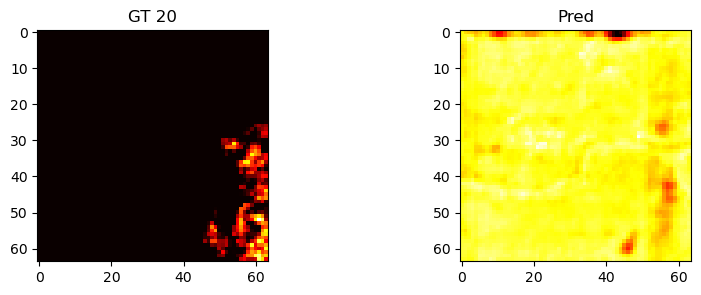

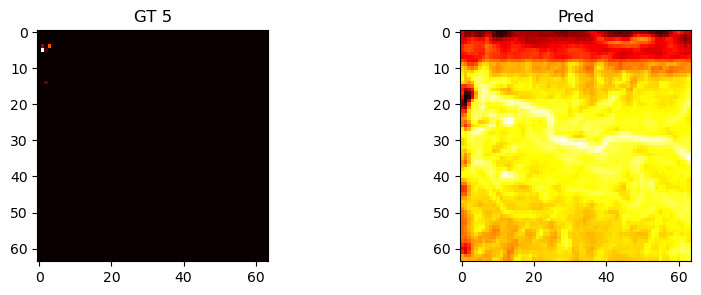

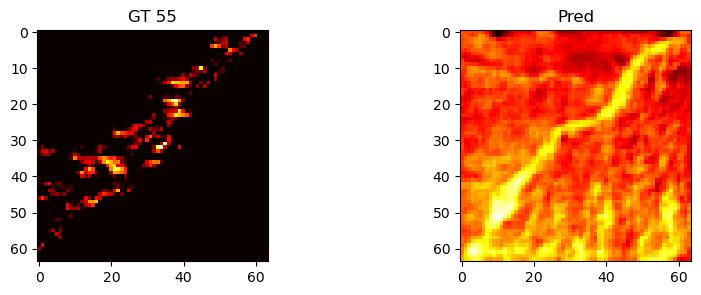

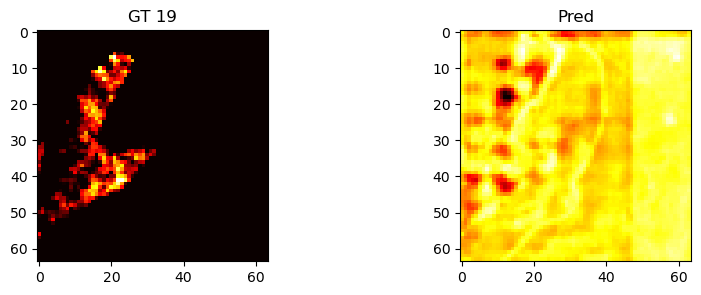

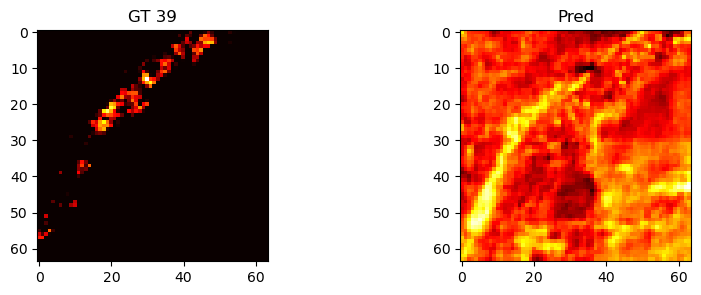

In [34]:
import random

model.eval()

indices = random.sample(range(len(X_test)), 5)

with torch.no_grad():
    preds = torch.sigmoid(model(X_test[indices]))

for j, i in enumerate(indices):
    plt.figure(figsize=(10,3))
    
    plt.subplot(1,2,1)
    plt.imshow(y_test[i][0].cpu(), cmap='hot')
    plt.title(f"GT {i}")
    
    plt.subplot(1,2,2)
    plt.imshow(preds[j][0].cpu(), cmap='hot')
    plt.title("Pred")
    
    plt.show()

In [273]:
import torch
model_cpu = model.to('cpu')
torch.save(model_cpu.state_dict(), 'unet_model.pth')

In [35]:
weights = model.fuse.weight.data.cpu().numpy()  # shape: (1,6,1,1)
weights = weights.reshape(-1)

In [36]:
print("Pred influence:", weights[0])
print("Band influences:", weights[1:])

Pred influence: -0.062225085
Band influences: [-0.07469071 -0.08013702  0.07403602  0.20012821  0.1731778  -0.21558136
 -0.20717154 -0.15334472  0.04037691 -0.12555633  0.1634552   0.15605752
 -0.03573457 -0.16161372 -0.02570186 -0.10352027 -0.19256797  0.09963374]


In [37]:
import numpy as np

w = weights  # your array

w_norm = w / (np.abs(w).sum() + 1e-6)

In [38]:
w_norm

array([-0.02653848, -0.03185496, -0.03417777,  0.03157575,  0.08535302,
        0.07385889, -0.09194366, -0.08835694, -0.06540025,  0.01722042,
       -0.05354873,  0.06971229,  0.06655724, -0.0152405 , -0.06892691,
       -0.01096163, -0.04415054, -0.08212864,  0.04249296], dtype=float32)

In [40]:
band_names= [
    "S1_VV", "S1_VH", "S1_VV-VH",

    "S2pre_B2", "S2pre_B3", "S2pre_B4", "S2pre_B8", "S2pre_NDVI",

    "Soil_Clay", "Soil_Sand", "Soil_Silt",

    "Elevation", "Slope", "Aspect", "Curvature", "Flow",

    "Rain_Avg", "Rain_Max","output"
]

In [41]:
for name, w in zip(band_names, weights):
    print(f"{name:15s} : {w:.4f}")

S1_VV           : -0.0622
S1_VH           : -0.0747
S1_VV-VH        : -0.0801
S2pre_B2        : 0.0740
S2pre_B3        : 0.2001
S2pre_B4        : 0.1732
S2pre_B8        : -0.2156
S2pre_NDVI      : -0.2072
Soil_Clay       : -0.1533
Soil_Sand       : 0.0404
Soil_Silt       : -0.1256
Elevation       : 0.1635
Slope           : 0.1561
Aspect          : -0.0357
Curvature       : -0.1616
Flow            : -0.0257
Rain_Avg        : -0.1035
Rain_Max        : -0.1926
output          : 0.0996


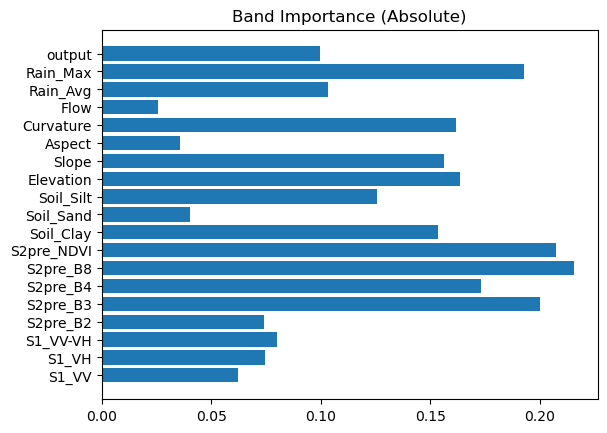

In [43]:
import matplotlib.pyplot as plt

plt.barh(band_names, np.abs(weights))
plt.title("Band Importance (Absolute)")
plt.show()